In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization

In [13]:
df = pd.read_csv("customer_sales.csv", delimiter=';')
df

,Customer_ID,Age,Gender,Income,Purchase_Amount,Product_Category
0,C001,25,Female,4500,250,Electronics
1,C002,42,Male,7200,420,Fashion
2,C003,31,Female,5100,315,Grocery
3,C004,55,Male,8900,520,Electronics
4,C005,28,Female,4800,275,Fashion
5,C006,36,Male,6100,360,Grocery
6,C007,47,Female,7600,430,Electronics
7,C008,23,Male,3900,220,Fashion
8,C009,39,Female,6800,410,Grocery
9,C010,52,Male,8500,500,Electronics


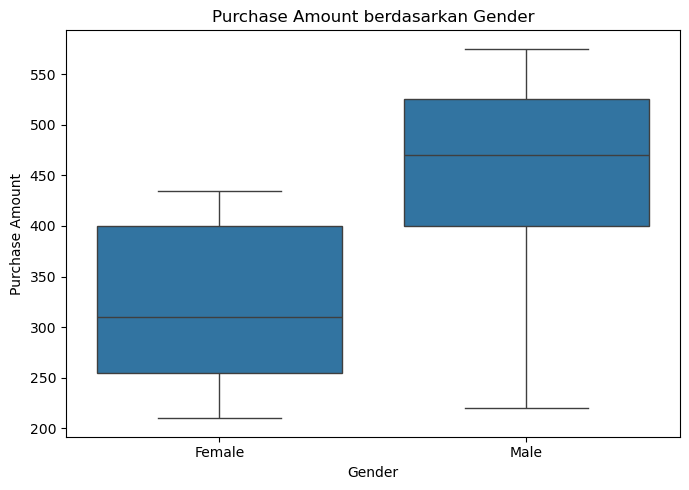

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Gender", y="Purchase_Amount")
plt.title("Purchase Amount berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")
plt.tight_layout()
plt.show()

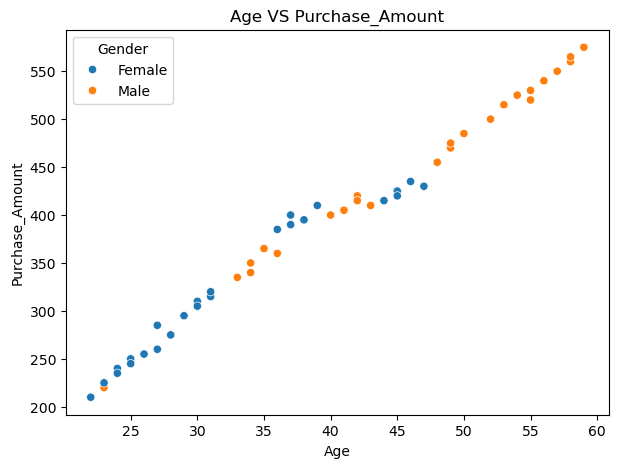

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Age", y="Purchase_Amount", hue="Gender")
plt.title("Age VS Purchase_Amount")
plt.xlabel("Age")
plt.ylabel("Purchase_Amount")
plt.show()

In [16]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[19, 29, 39, 49, 59],
    labels=["20-29", "30-39", "40-49", "50-59"],
    include_lowest=True
)

In [17]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Income', 'Purchase_Amount',
       'Product_Category', 'AgeGroup'],
      dtype='object')

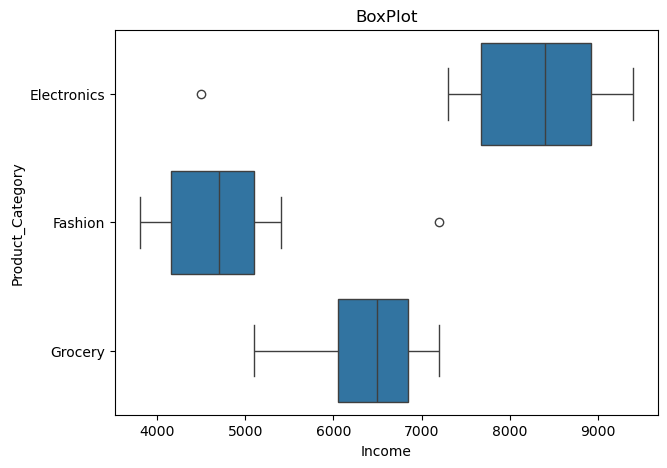

Product_Category
Electronics    20
Fashion        15
Grocery        15
Name: count, dtype: int64


In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Income", y="Product_Category")
plt.title("BoxPlot")
plt.show()

print(df["Product_Category"].value_counts(dropna=False, ascending=False))

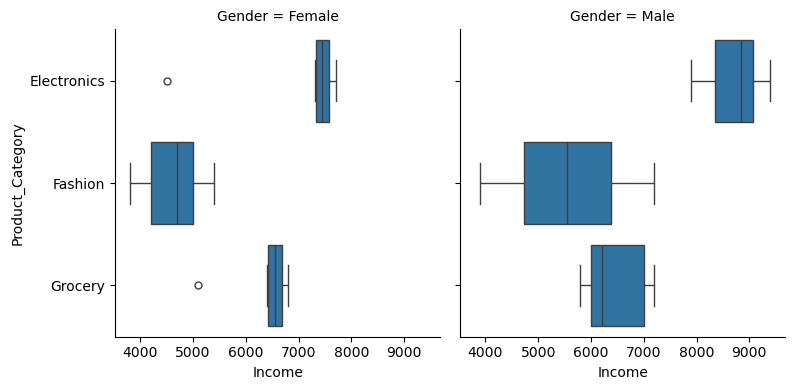

In [19]:
sns.catplot(
    data=df,
    x="Income",
    y="Product_Category",
    col="Gender",
    kind="box",
    height=4
)

plt.show()

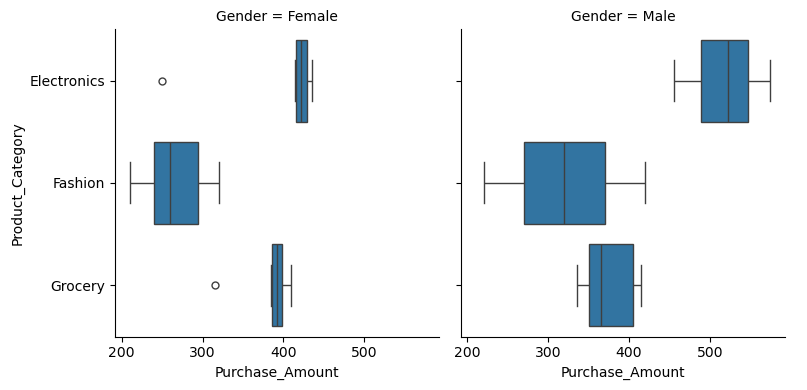

In [20]:
sns.catplot(
    data=df,
    x="Purchase_Amount",
    y="Product_Category",
    col="Gender",
    kind="box",
    height=4
)

plt.show()

In [21]:
df["IncomeGroup"] = pd.cut(
    df["Income"],
    bins = [0, 3000, 7000, 10000, float("inf")],
    labels = ["Low", "Middle", "High", "Very High"]
)

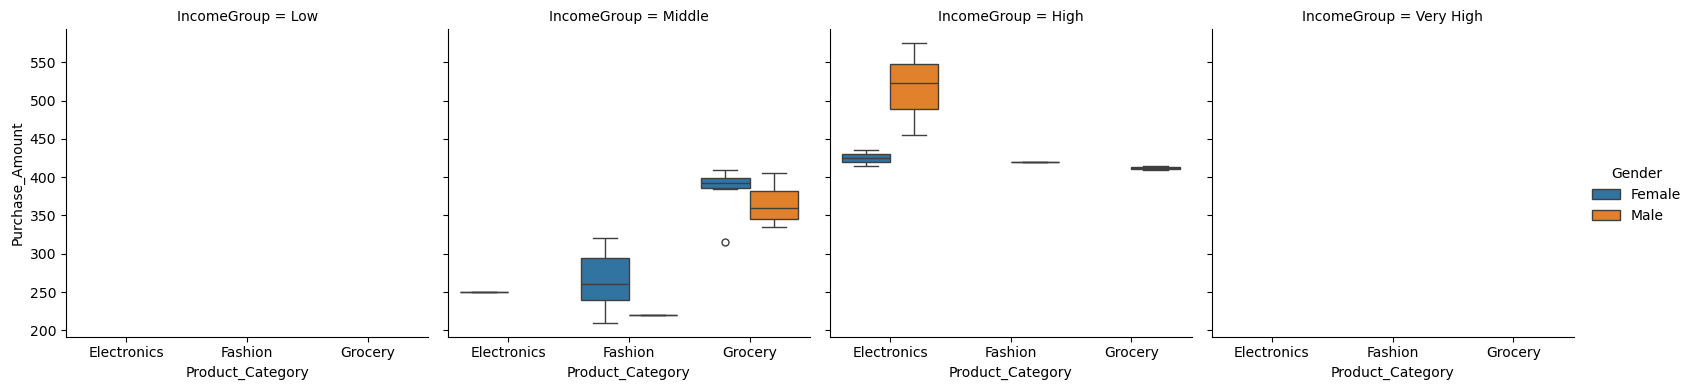

In [22]:
sns.catplot(
    data=df,
    x="Product_Category",
    y="Purchase_Amount",
    hue="Gender",
    col="IncomeGroup",
    kind="box",
    height=4,
    aspect=1
)
plt.show()

In [23]:
df["Product_Category"].value_counts()

Product_Category
Electronics    20
Fashion        15
Grocery        15
Name: count, dtype: int64

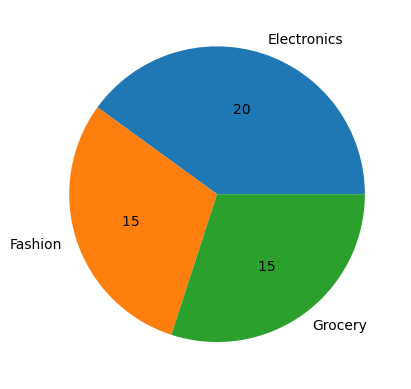

In [24]:
table = df["Product_Category"].value_counts()

def INT(Input):
    total = table.sum()
    total = int(round(Input * total / 100))
    return f"{total} "

plt.pie(
    table,
    labels=table.index,
    autopct=INT
)

plt.show()

In [25]:
df["Age"].value_counts()

Age
25    2
42    2
31    2
55    2
36    2
23    2
27    2
34    2
24    2
30    2
58    2
45    2
37    2
49    2
28    1
47    1
39    1
52    1
41    1
53    1
26    1
35    1
44    1
57    1
29    1
40    1
22    1
48    1
38    1
54    1
33    1
46    1
59    1
43    1
50    1
56    1
Name: count, dtype: int64

In [26]:
df

,Customer_ID,Age,Gender,Income,Purchase_Amount,Product_Category,AgeGroup,IncomeGroup
0,C001,25,Female,4500,250,Electronics,20-29,Middle
1,C002,42,Male,7200,420,Fashion,40-49,High
2,C003,31,Female,5100,315,Grocery,30-39,Middle
3,C004,55,Male,8900,520,Electronics,50-59,High
4,C005,28,Female,4800,275,Fashion,20-29,Middle
5,C006,36,Male,6100,360,Grocery,30-39,Middle
6,C007,47,Female,7600,430,Electronics,40-49,High
7,C008,23,Male,3900,220,Fashion,20-29,Middle
8,C009,39,Female,6800,410,Grocery,30-39,Middle
9,C010,52,Male,8500,500,Electronics,50-59,High


In [27]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins = [20, 30, 40, 50, 60],
    labels = ["20-29", "30-39", "40-49", "50-59"]
)

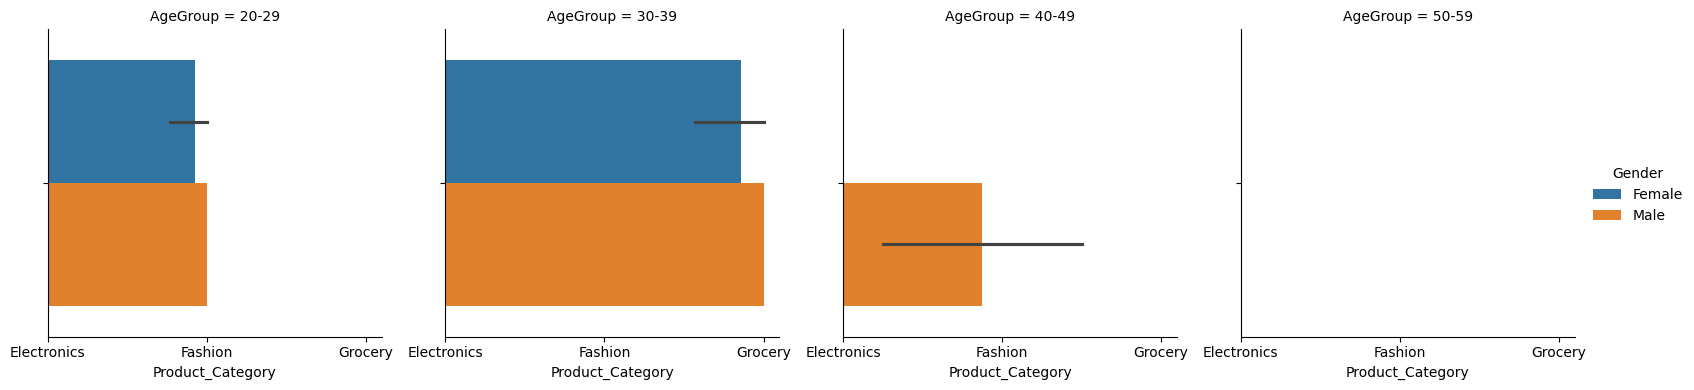

In [28]:
sns.catplot(
    data=df,
    x="Product_Category",
    hue="Gender",
    col="AgeGroup",
    height=4,
    aspect=1,
    kind="bar"
)

plt.show()

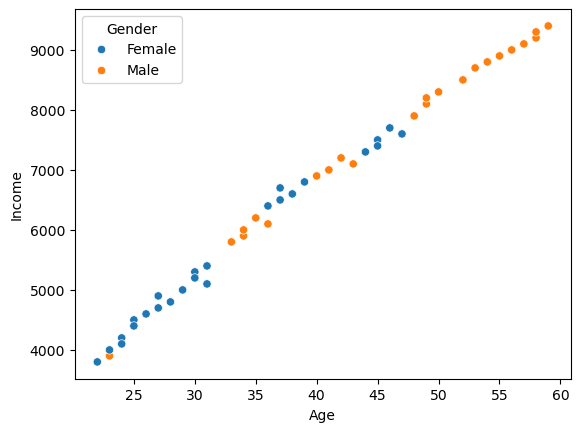

In [29]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Income",
    hue="Gender"
)

plt.show()

# Encoding

In [30]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# Mean Encoding

![Screenshot 2026-07-01 002001.png](<attachment:Screenshot 2026-07-01 002001.png>)

Cara memilih tipe uji statistik untuk mengecek korelasi antara feature yang akan di mean encod dengan target
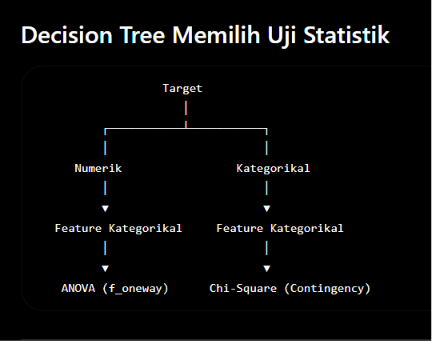

## Data Frame Yang Cocok Untuk Mean Encoding

In [31]:
import pandas as pd

df_good = pd.DataFrame({
    "City": [
        "Jakarta","Jakarta","Jakarta","Jakarta",
        "Bandung","Bandung","Bandung","Bandung",
        "Surabaya","Surabaya","Surabaya","Surabaya",
        "Medan","Medan","Medan","Medan"
    ],
    "Purchased": [
        1,1,1,0,      # Jakarta
        1,1,0,1,      # Bandung
        0,0,0,1,      # Surabaya
        0,0,0,0       # Medan
    ]
})

df_good

,City,Purchased
0,Jakarta,1
1,Jakarta,1
2,Jakarta,1
3,Jakarta,0
4,Bandung,1
5,Bandung,1
6,Bandung,0
7,Bandung,1
8,Surabaya,0
9,Surabaya,0


In [32]:
df_good["City"] = df_good["City"].map(df_good.groupby("City")["Purchased"].mean())
df_good

,City,Purchased
0,0.75,1
1,0.75,1
2,0.75,1
3,0.75,0
4,0.75,1
5,0.75,1
6,0.75,0
7,0.75,1
8,0.25,0
9,0.25,0


## Data Frame Yang Tidak Cocok Untuk Mean Encoding

In [33]:
import pandas as pd

df_bad = pd.DataFrame({
    "City":[
        "Jakarta","Jakarta","Jakarta","Jakarta",
        "Bandung","Bandung","Bandung","Bandung",
        "Surabaya","Surabaya","Surabaya","Surabaya",
        "Medan","Medan","Medan","Medan"
    ],
    "Purchased":[
        1,0,1,0,
        1,0,1,0,
        1,0,1,0,
        1,0,1,0
    ]
})

print(df_bad)

        City  Purchased
0    Jakarta          1
1    Jakarta          0
2    Jakarta          1
3    Jakarta          0
4    Bandung          1
5    Bandung          0
6    Bandung          1
7    Bandung          0
8   Surabaya          1
9   Surabaya          0
10  Surabaya          1
11  Surabaya          0
12     Medan          1
13     Medan          0
14     Medan          1
15     Medan          0


In [34]:
df_bad["City"] = df_bad["City"].map(df_bad.groupby("City")["Purchased"].mean())
df_bad

,City,Purchased
0,0.5,1
1,0.5,0
2,0.5,1
3,0.5,0
4,0.5,1
5,0.5,0
6,0.5,1
7,0.5,0
8,0.5,1
9,0.5,0


## Contoh Yang Menggunakan Smothing

In [35]:
import pandas as pd

df_smoothing = pd.DataFrame({
    "City":[
        "Jakarta","Jakarta","Jakarta","Jakarta","Jakarta",
        "Bandung","Bandung","Bandung","Bandung",
        "Surabaya","Surabaya","Surabaya",
        "Medan"
    ],
    "Purchased":[
        1,1,1,1,0,
        1,0,1,1,
        0,0,1,
        1
    ]
})

print(df_smoothing)

        City  Purchased
0    Jakarta          1
1    Jakarta          1
2    Jakarta          1
3    Jakarta          1
4    Jakarta          0
5    Bandung          1
6    Bandung          0
7    Bandung          1
8    Bandung          1
9   Surabaya          0
10  Surabaya          0
11  Surabaya          1
12     Medan          1


In [36]:
Coba = df_smoothing.groupby("City")["Purchased"].mean()
Coba

City
Bandung     0.750000
Jakarta     0.800000
Medan       1.000000
Surabaya    0.333333
Name: Purchased, dtype: float64

In [37]:
df_smoothing["City"].value_counts()

City
Jakarta     5
Bandung     4
Surabaya    3
Medan       1
Name: count, dtype: int64

In [ ]:
m = 1

Global_Mean = df_smoothing["Purchased"].mean()

Stats = df_smoothing.groupby("City")["Purchased"].agg(Mean="mean", Count="count")
Stats

,Mean,Count
City,,
Bandung,0.750000,4
Jakarta,0.800000,5
Medan,1.000000,1
Surabaya,0.333333,3


In [ ]:
Stats["Smoothing"] = (Stats["Count"] * Stats["Mean"] + Global_Mean * m) / (Stats["Count"] + m)

In [ ]:
df_smoothing["City"] = df_smoothing["City"].map(Stats["Smoothing"])

In [ ]:
df_smoothing

,City,Purchased
0,0.782051,1
1,0.782051,1
2,0.782051,1
3,0.782051,1
4,0.782051,0
5,0.738462,1
6,0.738462,0
7,0.738462,1
8,0.738462,1
9,0.423077,0


In [ ]:
m = 1

Stats = df_smoothing.groupby("City")["Purchased"].agg(Mean="mean", Count="Count", ABC="a")